# Second revision comments

## Load data

In [45]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import os
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

cd = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/"
original = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_OA.tsv"), separator="\t")
tempdir = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/"
figdir = cd + "results/manuscript_figures/revisions2/"
mpra = original.filter(pl.col("z_score").is_not_null())
os.makedirs(tempdir, exist_ok=True)

## overlap with ultra

In [4]:
original.select("OE") \
	.unique().select(column_1 = pl.col("OE").str.replace_all("-","\t"), id = pl.col("OE")).write_csv(os.path.join(tempdir,"CREs.bed"), separator="\t", include_header=False, quote_style='never')
     

In [11]:
!bedtools intersect -a "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/CREs.bed" \
	-b <(zcat /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/data/HepG2_MPRA_Ultra/coords_and_logratios.bed.gz) -wa -wb | cut -f 5,9,10 \
		> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/CREs.ultra.logratios.tsv"

In [14]:
!cat "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/CREs.ultra.logratios.tsv" | cut -f 2 | cut -c 1-6 | sort | uniq -c

   1662 DNaseP
    385 ENSG00


In [15]:
!wc -l  "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/CREs.ultra.logratios.tsv"

2047 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/CREs.ultra.logratios.tsv


In [6]:
ultra = pl.read_csv(os.path.join(cd,"results/luciferase_design/temp/enhancers.ultra.logratios.tsv"), separator="\t", has_header=False).rename({"column_1": "CRE", "column_2": "ultra_logratio"}) 
ccMPRAultra = original.rename({"OE": "CRE"}).join(ultra, on="CRE")
     

In [8]:
ccMPRAultra.height

148

<Axes: xlabel='z_score', ylabel='ultra_logratio'>

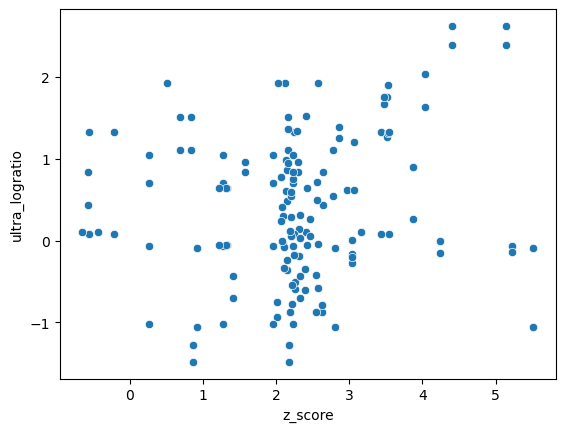

In [9]:
sns.scatterplot(data=ccMPRAultra.to_pandas(), x="z_score", y="ultra_logratio")

## Are there promoters with an activity far away from the average of their interactions?

In [16]:
mean_pair_activity = original.with_columns(mean_diff = pl.col("logFC").mean().over("promoter") - pl.col("promoter_only"))

<Axes: ylabel='Count'>

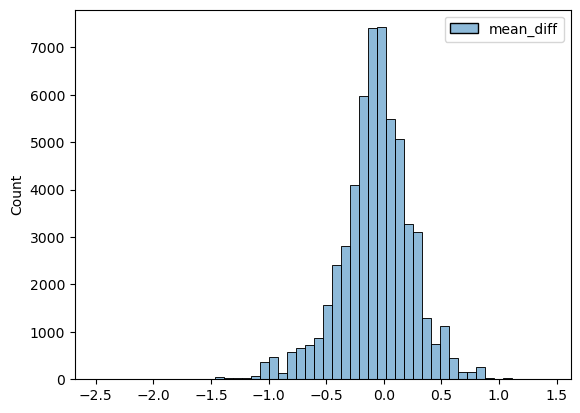

In [17]:
sns.histplot(mean_pair_activity.select("mean_diff").to_pandas(), bins=50)

## Correlation to activity without outlier sequence lengths

In [ ]:
bins = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv", 
	separator="\t", columns=[0,1,2],has_header=False, new_columns=["left_bin", "right_bin", "seq_id"])
coords = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv", 
	separator="\t",has_header=False, new_columns=["chrom", "start_left", "end_left", "start_right", "end_right", "seq_id"]) \
	.with_columns(left_length = (pl.col("end_left") - pl.col("start_left") + 1),
	              right_length = (pl.col("end_right") - pl.col("start_right") + 1))

## Stricter binning vs original

In [6]:
stricter = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/MPRA_analysis/CMPRA5/labeled_data_strictbinning_OA.tsv", separator="\t")

In [7]:
joined = stricter.select("promoter", "OE", "effect", "z_score", "logFC").join(mpra, on=["promoter", "OE"], suffix="_stricter")

<Axes: xlabel='logFC_stricter', ylabel='logFC'>

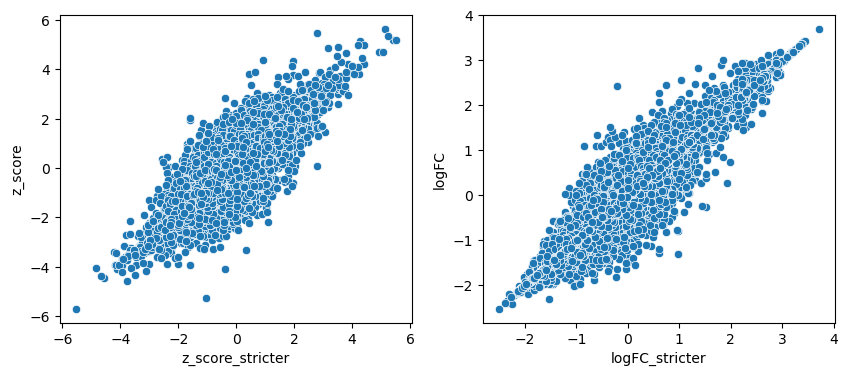

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
sns.scatterplot(data=joined.to_pandas(), x="z_score_stricter", y="z_score", ax=axs[0])
from scipy import stats

tips = sns.load_dataset("tips")

values = np.vstack([tips["total_bill"], tips["tip"]])
kernel = stats.gaussian_kde(values)(values)sns.scatterplot(data=joined.to_pandas(), x="logFC_stricter", y="logFC", ax=axs[1])

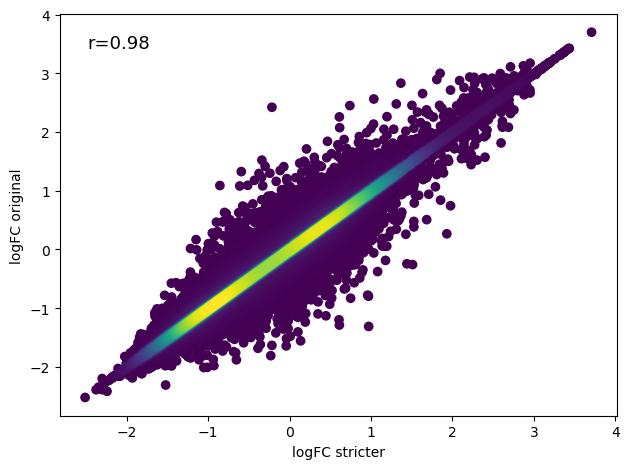

In [16]:
from scipy import stats


values = np.vstack([joined.select("logFC_stricter").to_numpy().flatten(), joined.select("logFC").to_numpy().flatten()])
kernel = stats.gaussian_kde(values)(values)
#sns.scatterplot(data=joined.to_pandas(), x="logFC_stricter", y="logFC", c = kernel, cmap="viridis")
idx = kernel.argsort()
x, y, kernel = joined.select("logFC_stricter").to_numpy().flatten()[idx], joined.select("logFC").to_numpy().flatten()[idx], kernel[idx]
plt.scatter(x, y, c=kernel)
plt.xlabel("logFC stricter")
plt.ylabel("logFC original")
ax = plt.gca()
ax.text(0.05, 0.95, "r=0.98", transform=ax.transAxes, ha="left", va="top", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(figdir, "logFC_comparison_stricter.pdf"), format="pdf")

In [14]:
joined.select(pl.corr("z_score", "z_score_stricter"), pl.corr("logFC", "logFC_stricter"))

z_score,logFC
f64,f64
0.889584,0.979954


In [21]:
mpra.filter(pl.col("effect") != "no effect").height / mpra.filter(pl.col("effect").is_not_null()).height

0.037592133270005455

## visualizing z-score

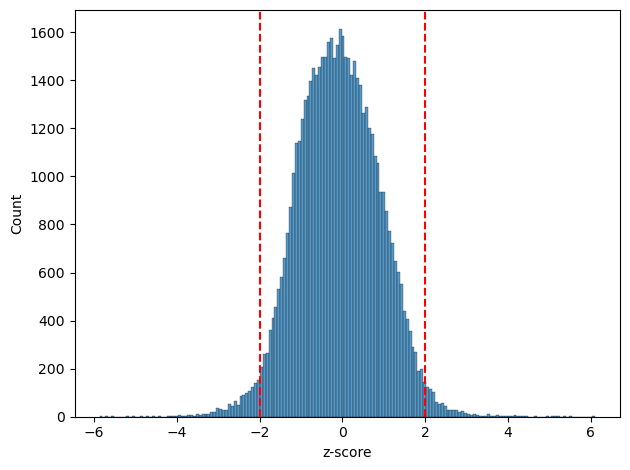

In [4]:
sns.histplot(mpra,x='z_score')
ax = plt.gca()
ax.axvline(-2, color="red", linestyle="--", linewidth=1.5)
ax.axvline(2, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("z-score")
plt.tight_layout()
plt.savefig(os.path.join(figdir, "z_score_distribution.pdf"), format="pdf")

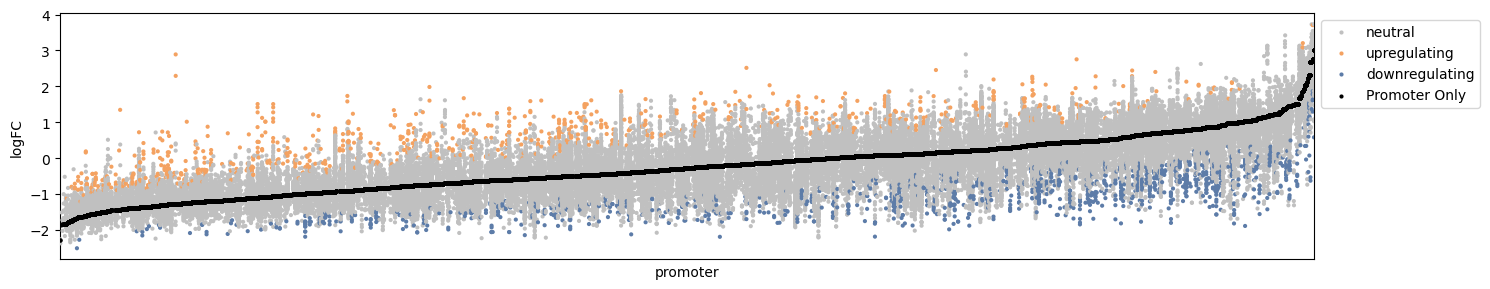

In [3]:
fig, ax = plt.subplots(figsize=(15,3))
n_promoters = mpra.select(pl.n_unique("promoter")).item()
# This is for a random subset
# subset = mpra.with_columns(
# 	index = pl.col("promoter").rank("dense")).filter(
#     pl.col("index").is_in(np.random.choice(n_promoters, 10))
# )
# # This is for the most and least active interactors
# subset = mpra.filter(pl.col("promoter").is_not_null()).with_columns(nr_up = pl.when(pl.col("effect") == "upregulating").then(pl.lit(1)).otherwise(pl.lit(0)).sum().over("promoter"), 
# 						   nr_down = pl.when(pl.col("effect") == "downregulating").then(pl.lit(1)).otherwise(pl.lit(0)).sum().over("promoter")
# 					   )
# most = subset.group_by("promoter").agg(pl.col("nr_up").max()).sort("nr_up", descending=True).head(5)
# least = subset.group_by("promoter").agg(pl.col("nr_down").max()).sort("nr_down", descending=True).head(5)
# middle = subset.group_by("promoter").agg(pl.col("nr_up").max()).sort("nr_up").head(subset.n_unique("promoter")*3//4).tail(500).sample(5)
# subset = pl.concat([mpra.join(most, on="promoter", how="semi"), mpra.join(middle, on="promoter", how="semi"), mpra.join(least, on="promoter", how="semi")])
# highest = mpra.filter(pl.col("promoter").is_not_null()).group_by("promoter").agg(pl.col("z_score").max()).sort("z_score", descending=True).head(5)
# lowest = mpra.filter(pl.col("promoter").is_not_null()).group_by("promoter").agg(pl.col("z_score").min()).sort("z_score").head(5)
# subset = pl.concat([mpra.join(highest, on="promoter", how="semi"), mpra.join(lowest, on="promoter", how="semi")])
ax = sns.stripplot(mpra.with_columns(effect = pl.when(pl.col("effect") == "no effect").then(pl.lit("neutral")).otherwise(pl.col("effect")))
				   .sort("promoter_only").to_pandas(), y="logFC", x="promoter", hue="effect", hue_order=["neutral", "upregulating", "downregulating"]
				   , size=3, palette=["silver", "#F4A261", "#5D7CA8"])
sns.stripplot(mpra.sort("promoter_only").to_pandas(), x="promoter", y="promoter_only", color="black",label="Promoter Only", ax = ax, size=3)
plt.xticks(rotation=60, fontsize=8, ha="right")
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), loc='best', bbox_to_anchor=(1, 1))
ax.set_xticks([])
ax.tick_params(axis="x", which="both", length=0)
plt.tight_layout()
plt.savefig(os.path.join(figdir, "promoter_effects_stripplot.pdf"), format="pdf")

## yet another MPRA design

### Filtering for promoters containing TSS (basically all sequences anyways)

In [46]:
filtered = mpra.with_columns(pl.when((pl.col("left_bin") == pl.col("promoter"))& (pl.col("tss_left") == "yes")).then(True)
				  .when((pl.col("right_bin") == pl.col("promoter"))& (pl.col("tss_right") == "yes")).then(True)
				  .otherwise(False).alias("promoter_tss"))

In [47]:
length_filtered_cres = filtered.filter("promoter_tss").select("z_score", "target_genes", "OE", "effect", "promoter", "left_bin", "right_bin") \
	.with_columns(promoter_length = pl.col("promoter").str.split("-").list.get(2).cast(pl.Int64) - pl.col("promoter").str.split("-").list.get(1).cast(pl.Int64),
			   CRE_length = pl.col("OE").str.split("-").list.get(2).cast(pl.Int64) - pl.col("OE").str.split("-").list.get(1).cast(pl.Int64)) \
				.filter(pl.col("promoter_length") >= 100).filter(pl.col("CRE_length") >= 100)#.select(pl.col("effect").value_counts())
	

In [109]:
length_filtered_cres.select(pl.col("effect").value_counts())

effect
struct[2]
"{""downregulating"",742}"
"{""upregulating"",238}"
"{""no effect"",19648}"


### Filtering for minimal sequence length difference in bins

In [5]:
bins = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv", 
	separator="\t", columns=[0,1,2],has_header=False, new_columns=["left_bin", "right_bin", "seq_id"])
coords = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv", 
	separator="\t",has_header=False, new_columns=["chrom", "start_left", "end_left", "start_right", "end_right", "seq_id"]) \
	.with_columns(left_length = (pl.col("end_left") - pl.col("start_left") + 1),
	              right_length = (pl.col(
					  "end_right") - pl.col("start_right") + 1))
pl.Config.set_fmt_str_lengths(50)
bin_with_coords = bins.join(coords, on="seq_id")
bin_with_coords_stds = bin_with_coords \
	.group_by(["left_bin", "right_bin"]).agg(pl.col("left_length", "right_length").std())#.unpivot(index=cs.matches("bin"), value_name="length std")

In [48]:
filtered_cres = length_filtered_cres.join(bin_with_coords_stds, on=["left_bin", "right_bin"]).fill_null(0) \
	.filter(pl.col("left_length") <= 20).filter(pl.col("right_length") <= 20) #.select(pl.col("effect").value_counts())

In [49]:
all_filtered_cres = filtered_cres
filtered_cres = filtered_cres.filter(pl.col("effect") != "no effect")

In [112]:
filtered_cres.select(pl.col("effect").value_counts())

effect
struct[2]
"{""upregulating"",180}"
"{""downregulating"",449}"


In [127]:
length_filtered_cres.join(bin_with_coords_stds, on=["left_bin", "right_bin"]).fill_null(0).filter(pl.col("OE").str.contains("r20-35768547-35768902-"))

z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length
f64,str,str,str,str,str,str,i64,i64,f64,f64
-3.129785,"""RBM39""","""chr20-35768547-35768902-.""","""downregulating""","""chr20-35742180-35742625--""","""chr20-35742180-35742625--""","""chr20-35768547-35768902-.""",445,355,131.073771,1.732051


### Getting original bin orders

Aha: I think here I am using the already left to right ordered bins, maybe that's why i don't get all seqs

In [17]:
filtered_cres.select("OE", "promoter").write_csv(os.path.join(tempdir, "bins.tsv"), separator="\t", include_header=False)

In [9]:
# taking only those sequences that had assigned barcodes
!zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/mprasnakeflow/results/assigned_bcs_part1and2.tsv.gz' | cut -f -2,4,6,8,10,12,14 | awk 'NR > 1 && NF >=5' | cut -f 2 | sed 's/>//' > $seqids

/bin/bash: line 1: $seqids: ambiguous redirect
^C


In [18]:
seqids = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv"
bins = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv"

In [ ]:
filtered_cres.select("OE", "promoter").write_csv(os.path.join(tempdir, "bins.tsv"), separator="\t", include_header=False)

In [32]:
!awk -v FS="\t" '{print $1"-"$2"-"$3"-.S"$5"-"$6"-"$7"-"$8"\t"$9"\t"$4}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_merged.bed.gz') \
	| grep -Fwf <(sed 's/\t/S/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv") | sed 's/S/\t/' > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_seqs.tsv"

In [105]:
filtered_cres.select("promoter", "OE").write_csv(os.path.join(tempdir, "bins.tsv"), separator="\t", include_header=False)

In [106]:
!awk -v FS="\t" '{print $1"-"$2"-"$3"-"$4"S"$5"-"$6"-"$7"-.\t"$9"\t"$8}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_merged.bed.gz') \
	| grep -Fwf <(sed 's/\t/S/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv") | sed 's/S/\t/' > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_seqs_prom_oe.tsv"

In [36]:
# Now taking only those sequences with assigned barcodes
!awk '{split($3,seqs,","); for (i in seqs) print $1"\t"$2"\t"$4"\t"seqs[i]}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_seqs.tsv" | sort | uniq | grep -Fwf "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_used_seqs.tsv"

In [107]:
!awk '{split($3,seqs,","); for (i in seqs) print $1"\t"$2"\t"$4"\t"seqs[i]}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_seqs_prom_oe.tsv" | sort | uniq | grep -Fwf "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_used_seqs_prom_oe.tsv"

In [7]:
prom_cre = filtered_cres.join(
	pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_used_seqs_prom_oe.tsv", separator="\t", has_header=False, new_columns=["promoter", "OE", "OE_sign", "seq_id"])
	, on=["promoter", "OE"])

In [8]:
cre_prom = filtered_cres.join(
	pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_bins_with_used_seqs.tsv", separator="\t", has_header=False, new_columns=["OE", "promoter", "OE_sign", "seq_id"])
	, on=["promoter", "OE"])

In [9]:
cre_prom.select(pl.col("effect").value_counts())

effect
struct[2]
"{""upregulating"",87}"
"{""downregulating"",113}"


In [44]:
cre_prom.group_by("promoter", "OE", "z_score").agg(pl.col("OE_sign").mode().first())

promoter,OE,z_score,OE_sign
str,str,f64,str
"""chr5-134176722-134177047--""","""chr5-134026552-134026799-.""",2.215802,"""+"""
"""chr1-147172040-147172482--""","""chr1-147247863-147248063-.""",-2.026742,"""-"""
"""chr16-71895486-71895846-+""","""chr16-71938500-71938719-.""",-2.086115,"""+"""
"""chr12-121888615-121888963-+""","""chr12-121950174-121950373-.""",2.11159,"""-"""
"""chr17-81294886-81295818--""","""chr17-81422250-81422433-.""",2.181266,"""+"""
…,…,…,…
"""chr16-67226845-67227442-+""","""chr16-67369771-67369998-.""",2.16,"""+"""
"""chr20-45415817-45416355-+""","""chr20-45837510-45837637-.""",-2.168172,"""+"""
"""chr20-34955548-34956391--""","""chr20-35056057-35056249-.""",-2.438062,"""+"""


In [12]:
prom_cre.select(pl.col("effect").value_counts())

effect
struct[2]
"{""downregulating"",312}"
"{""upregulating"",93}"


In [9]:
filtered_cres.join(pl.concat([prom_cre,cre_prom]), on=["OE", "promoter"]).height

605

In [15]:
filtered_cres.join(pl.concat([prom_cre,cre_prom]), on=["OE", "promoter"], how="anti").filter(pl.col("effect") == "upregulating").height

19

In [16]:
prom_cre.join(cre_prom.select(pl.exclude("OE_sign")), on=["OE", "promoter"], how="anti").filter(pl.col("effect") == "upregulating").sort("z_score", descending=True).head()

z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length,OE_sign,seq_id
f64,str,str,str,str,str,str,i64,i64,f64,f64,str,str
5.226543,"""RNASE3""","""chr14-20971623-20972006-.""","""upregulating""","""chr14-20891166-20891415-+""","""chr14-20891166-20891415-+""","""chr14-20971623-20972006-.""",249,383,0.0,0.0,"""-""","""V350161981_L03_contig_709414"""
4.004004,"""DMBT1""","""chr10-122479620-122479771-.""","""upregulating""","""chr10-122560249-122560775-+""","""chr10-122479620-122479771-.""","""chr10-122560249-122560775-+""",526,151,0.0,0.0,"""+""","""m84066_240623_102831_s3/104401011/ccs"""
3.88121,"""A2ML1""","""chr12-8687887-8688146-.""","""upregulating""","""chr12-8822608-8822796-+""","""chr12-8687887-8688146-.""","""chr12-8822608-8822796-+""",188,259,0.0,0.0,"""-""","""m84066_240623_102831_s3/109055515/ccs"""
3.823608,"""MGME1""","""chr20-17838766-17838878-.""","""upregulating""","""chr20-17968096-17968866-+""","""chr20-17838766-17838878-.""","""chr20-17968096-17968866-+""",770,112,0.0,0.0,"""-""","""m84066_240516_024507_s2/199890267/ccs"""
3.748553,"""MPHOSPH9""","""chr12-123010780-123011030-.""","""upregulating""","""chr12-123233452-123233845--""","""chr12-123010780-123011030-.""","""chr12-123233452-123233845--""",393,250,0.0,0.0,"""-""","""V350161981_L03_contig_3383347"""


### Does the filtered set contain the luciferase tested sequences?

In [81]:
length_filtered_cres.join(bin_with_coords_stds, on=["left_bin", "right_bin"]).fill_null(0).filter(pl.col("target_genes") == "CFAP410")

z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length
f64,str,str,str,str,str,str,i64,i64,f64,f64


In [35]:
length_filtered_cres.join(bin_with_coords_stds, on=["left_bin", "right_bin"]).fill_null(0) .filter(pl.col("target_genes") == "RIOK1").filter(pl.col("OE").str.contains("748"))


z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length
f64,str,str,str,str,str,str,i64,i64,f64,f64
-3.061273,"""RIOK1""","""chr6-7389927-7390748-.""","""downregulating""","""chr6-7389289-7389836-+""","""chr6-7389289-7389836-+""","""chr6-7389927-7390748-.""",547,821,0.0,165.580796


In [36]:
prom_cre.filter(pl.col("target_genes") == "KRR1")

z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length,seq_id
f64,str,str,str,str,str,str,i64,i64,f64,f64,str
2.832694,"""KRR1""","""chr12-76073631-76074011-.""","""upregulating""","""chr12-75510888-75511698--""","""chr12-75510888-75511698--""","""chr12-76073631-76074011-.""",810,380,0.0,0.0,"""V350161981_L03_contig_1193282"""
2.070565,"""KRR1""","""chr12-75589552-75589713-.""","""upregulating""","""chr12-75510888-75511698--""","""chr12-75510888-75511698--""","""chr12-75589552-75589713-.""",810,161,0.0,0.0,"""m84066_240623_122801_s1/35720268/ccs"""


In [32]:
filtered_cres.filter(pl.col("target_genes") == "RIOK1").filter(pl.col("OE").str.contains("748"))

z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length
f64,str,str,str,str,str,str,i64,i64,f64,f64


### Write to files

In [60]:
mpra.filter(pl.col("OE").str.contains('chr16-18767'))

logFC,adj.P.Val,P.Value,left_bin,right_bin,nr_reads,nr_seqs,tss_left,tss_right,repeats_left,repeats_right,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std,z_score,promoter_repeats,OE_repeats
f64,f64,f64,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64,str,str
3.084496,1.7048e-25,2.8174e-27,"""chr16-18767630-18767760-.""","""chr16-18790192-18790610--""",5,1,"""no""","""yes""","""MIR,Alu""","""Alu,Alu""",null,"""pELS,CTCF-bound,PLS,CTCF-bound""","""unlabeled""","""positivecontrol""","""unlabeled""","""RPS15A""","""positive - other""","""PLS - ELS""",22706.0,"""RPS15A""","""upregulating""","""chr16-18790192-18790610--""","""chr16-18767630-18767760-.""",1.866512,0.576251,2.113634,"""Alu,Alu""","""MIR,Alu"""
3.085245,1.8820e-25,3.1287e-27,"""chr16-18767495-18767629-.""","""chr16-18790192-18790610--""",5,1,"""no""","""yes""","""MIR""","""Alu,Alu""","""dELS""","""pELS,CTCF-bound,PLS,CTCF-bound""","""unlabeled""","""positivecontrol""","""unlabeled""","""RPS15A""","""positive - other""","""PLS - ELS""",22839.0,"""RPS15A""","""upregulating""","""chr16-18790192-18790610--""","""chr16-18767495-18767629-.""",1.866512,0.576251,2.114935,"""Alu,Alu""","""MIR"""


In [62]:
selected_cre_prom = cre_prom.filter(pl.col("effect") == "upregulating").group_by("promoter", "OE", "target_genes","z_score").agg(pl.col("OE_sign").mode().first()).filter(pl.col("OE").str.contains("chr16-18767").not_())
pl.concat([selected_cre_prom
		   .select(pl.col("OE").str.replace("-", "\t").str.replace("-", "\t").str.replace("-\\.", ""), pl.concat_str(pl.col("OE").str.head(-1), "OE_sign").alias("name"), "OE_sign", "target_genes", comments = "OE"),
 pl.DataFrame({ "OE": ["chr6	41768791	41769144", "chr16	18767495	18767760"],
			   "name": ["chr6-41768791-41769144--", "chr16-18767495-18767760--"],
 				"OE_sign" : ["-", "-"],
				"target_genes": ["TOMM6", "RPS15A"],
				"comments": ["chr6-41768791-41769144-.", "chr16-18767495-18767629-."]})]) \
	.sort("OE") \
	.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/enhancers_cre_promoter_order.bed", separator="\t", include_header=False, quote_style='never')


I will manually add the TOMM6 enhancer which we tested in the luciferase: chr6-41768791-41769144-- , and merge the two bins that are adjacent (RPS15A).  
For the CRE-prom bins, the name is OE_promoter, for the prom-CRE bins it's promoter_OE.  
Here are the 19 Promoter - CRE order sequences 

In [48]:
selected_prom_cre = prom_cre.join(cre_prom, on=["OE", "promoter"], how="anti").filter(pl.col("effect") == "upregulating").group_by("promoter", "OE", "target_genes","z_score").agg(pl.col("OE_sign").mode().first()) \
	.sort("z_score", descending=True).head(19) 
selected_prom_cre.select(pl.col("OE").str.replace("-", "\t").str.replace("-", "\t").str.replace("-\\.", ""),  pl.concat_str(pl.col("OE").str.head(-1), "OE_sign").alias("name"), "OE_sign", "target_genes", comments = "OE") \
	.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/enhancers_prom_cre_order.bed", separator="\t", include_header=False, quote_style='never')

Silencers: (only 93, because I need to include those that were tested in the luciferase but didn't pass the filter as well)  
In the silencers file, I am manually merging two adjacend RIOK1 bins.

In [15]:
selected_silencers = cre_prom.filter(pl.col("effect") == "downregulating").group_by("promoter", "OE", "target_genes","z_score").agg(pl.col("OE_sign").mode().first()).sort("z_score").head(93) 
formated_silencers	= selected_silencers.select(pl.col("OE").str.replace("-", "\t").str.replace("-", "\t").str.replace("-\\.", ""),  pl.concat_str(pl.col("OE").str.head(-1), "OE_sign").alias("name"), "OE_sign", "target_genes", comments = "OE") 

Here I am adding the 7 luciferase sequences that did not pass the test.


In [88]:
additional_silencers = pl.DataFrame({
	"OE": ["chr1	44988261	44988729","chr14	23028094	23028833",
		  	"chr20	31760595	31760829", "chr20	50957061	50957712",
			"chr2	73821103	73821684", "chr20	35768547	35768902",
			"chr6	7389927	7390748", "chr6	7389837	7390753", "chr6	7389837	7390984",
			"chr14	44988261	44988729", "chr14	23028094	23028833",
			"chr20	50957061	50957712"],
	"name": ["chr1-44988261-44988729--","chr14-23028094-23028833-+",
		  	"chr20-31760595-31760829--", "chr20-50957061-50957712-+",
			"chr2-73821103-73821684-+", "chr20-35768547-35768902-+",
			"chr6-7389927-7390748-+_bin", "chr6-7389927-7390748-+_seq1",
			"chr6-7389927-7390748-+_seq2", "chr14-44988261-44988729--",
			"chr14-23028094-23028833-+", "chr20-50957061-50957712-+"],
	"OE_sign": ["-", "+", "-", "+", "+", "+", "+", "+", "+", "-", "+", "+"],
	"target_genes": ["UROD", "PSMB5", "BCL2L1", "DPM1", "STAMBP", "RBM39", "RIOK1", "RIOK1", "RIOK1", "UROD", "PSMB5", "DPM1"],
	"comments": ["chr1-44988261-44988729-.","chr14-23028094-23028833-.",
		  	"chr20-31760595-31760829-.", "chr20-50957061-50957712-.",
			"chr2-73821103-73821684-.", "chr20-35768547-35768902-.",
			"chr6-7389927-7390748-.", "chr6-7389927-7390748-.",
			"chr6-7389927-7390748-.", "chr14-44988261-44988729-.", 
			"chr14-23028094-23028833-.", "chr20-50957061-50957712-."]
})

In [89]:
pl.concat([formated_silencers, additional_silencers]) \
	.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/silencers_cre_promoter_order.bed", separator="\t", include_header=False, quote_style='never')

Okay now let's write the promoters to a file:
(need to manually add TOMM6 still)

In [63]:
pl.concat([selected_cre_prom, selected_prom_cre]).unique(["promoter", "OE"]) \
	.select(pl.col("promoter").str.replace("-", "\t").str.replace("-", "\t").str.replace("-.", ""), pl.col("promoter").alias("name"), pl.col("promoter").str.tail(1).alias("sign")
	, "target_genes", comments = "promoter").vstack(pl.DataFrame({
		"promoter": ["chr6	41786908	41788053"],
		"name": ["chr6-41787436-41787975-+_seq"],
		"sign": ["+"],
		"target_genes": ["TOMM6"],
		"comments": ["chr6-41787436-41787975-+"]
	})) \
	.sort("promoter").unique() \
	.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/upregulated_promoters.bed", separator="\t", include_header=False, quote_style='never')

In [28]:
additional_downregulated_promoters = pl.DataFrame({
    "promoter": [
        "chr20\t31723132\t31724030",
        "chr20\t31723135\t31723859",
        "chr20\t31722862\t31724037",
        "chr2\t73828674\t73829059",
        "chr2\t73828431\t73829061",
        "chr20\t35741955\t35742631",
		"chr14\t23034803\t23035146",
		"chr20\t50958049\t50958627"
    ],
    "name": [
        "chr20-31723132-31724030--_bin",
        "chr20-31723132-31724030--_seq1",
        "chr20-31723132-31724030--_seq2",
        "chr2-73828674-73829059-+_bin",
        "chr2-73828674-73829059-+_seq1",
        "chr20-35742180-35742625--_seq1",
		"chr14-23034803-23035146--",
		"chr20-50958049-50958627--"
    ],
    "sign": ["-", "-", "-", "+", "+", "-", "-", "-"],
    "target_genes": ["BCL2L1", "BCL2L1", "BCL2L1", "STAMBP", "STAMBP", "RBM39", "PSMB5", "DPM1"],
    "comments": [
        "chr20-31723132-31724030--",
        "chr20-31723132-31724030--",
        "chr20-31723132-31724030--",
        "chr2-73828674-73829059-+",
        "chr2-73828674-73829059-+",
        "chr20-35742180-35742625--",
		"chr14-23034803-23035146--",
		"chr20-50958049-50958627--"
    ]
})

In [29]:
selected_silencers.unique(["promoter", "OE"]) \
	.select(pl.col("promoter").str.replace("-", "\t").str.replace("-", "\t").str.replace("-.", ""), pl.col("promoter").alias("name"), pl.col("promoter").str.tail(1).alias("sign")
	, "target_genes", comments = "promoter").vstack(additional_downregulated_promoters) \
	.sort("promoter").unique() \
	.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/downregulated_promoters.bed", separator="\t", include_header=False, quote_style='never')

### Creating a combination lookup table
Don't forget the enhancer bin that I merged

In [75]:
lookup = pl.concat([
	selected_cre_prom.select(pl.concat_str(pl.col("OE").str.head(-1), "OE_sign"), "promoter", "target_genes", cre_prom_order = pl.lit(True), enhancer = pl.lit(True)),
	selected_prom_cre.select(pl.concat_str(pl.col("OE").str.head(-1), "OE_sign"), "promoter", "target_genes", cre_prom_order = pl.lit(False), enhancer = pl.lit(True)),
	selected_silencers.select(pl.concat_str(pl.col("OE").str.head(-1), "OE_sign"), "promoter", "target_genes", cre_prom_order = pl.lit(True), enhancer = pl.lit(False)),
	pl.DataFrame({
		"OE": ["chr6-41768791-41769144--", "chr6-41768791-41769144--", # TOMM6 enhancer with two promoters
		 "chr1-44988261-44988729--", # UROD,
		 "chr14-23028094-23028833-+", # PSMB5
		 "chr20-31760595-31760829--", "chr20-31760595-31760829--", "chr20-31760595-31760829--", # BCL2L1 enhancer with three promoters
		 "chr20-50957061-50957712-+", # DPM1,
		 "chr2-73821103-73821684-+", "chr2-73821103-73821684-+", # STAMBP enhancer with two promoters
		 "chr20-35768547-35768902-+", "chr20-35768547-35768902-+", # RBM39 enhancer with two promoters
		 "chr6-7389927-7390748-+_bin", "chr6-7389927-7390748-+_seq1", "chr6-7389927-7390748-+_seq2", # RIOK1 three enhancers with one promoter
		 "chr16-18767495-18767760--" # RPS15A two merged enhancers with one promoter
		 ],
		"promoter": ["chr6-41787436-41787975-+", "chr6-41787436-41787975-+_seq", # TOMM6 promoters
			   "chr1-45012148-45012412-+", # UROD
			   "chr14-23034803-23035146--", # PSMB5
				"chr20-31723132-31724030--_bin", "chr20-31723132-31724030--_seq1", "chr20-31723132-31724030--_seq2", # BCL2L1 promoters
				"chr20-50958049-50958627--", # DPM1,
				"chr2-73828674-73829059-+_bin", "chr2-73828674-73829059-+_seq1", # STAMBP promoters
				"chr20-35742180-35742625--", "chr20-35742180-35742625--_seq1", # RBM39 promoters
				"chr6-7389289-7389836-+", "chr6-7389289-7389836-+", "chr6-7389289-7389836-+", # RIOK1 
				"chr16-18790192-18790610--" # RPS15A
			   ],
		"target_genes": ["TOMM6", "TOMM6", "UROD", "PSMB5", "BCL2L1", "BCL2L1", "BCL2L1", 
				   "DPM1", "STAMBP", "STAMBP", "RBM39", "RBM39", "RIOK1", "RIOK1", "RIOK1", "RPS15A"],
		"cre_prom_order": [True] * 16,
		"enhancer": [True] * 2 + [False] * 13 + [True] 
	})]).rename({"OE": "CRE"})

In [76]:
lookup.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/prom_cre_lookup_table.tsv", separator="\t", include_header=True, quote_style='never')

### writing fasta files

In [176]:
!bedtools getfasta -fi /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/resources/reference/hg38.fa \
	-bed <(cat /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/enhancers_cre_promoter_order.bed \
		/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/enhancers_prom_cre_order.bed) \
	-nameOnly -s -fo /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/enhancers.fa


In [177]:
!bedtools getfasta -fi /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/resources/reference/hg38.fa \
	-bed /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/silencers_cre_promoter_order.bed \
	-nameOnly -s -fo /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/silencers.fa


In [178]:
!bedtools getfasta -fi /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/resources/reference/hg38.fa \
	-bed /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/upregulated_promoters.bed \
	-nameOnly -s -fo /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/upregulated_promoters.fa

In [179]:
!bedtools getfasta -fi /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/resources/reference/hg38.fa \
	-bed /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/downregulated_promoters.bed \
	-nameOnly -s -fo /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/downregulated_promoters.fa

In [180]:
!sed -E '/^>/!{{s/^ATC//I;s/GAT$//I}}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/enhancers.fa" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/enhancers.trimmed.fa" 
!sed -E '/^>/!{{s/^ATC//I;s/GAT$//I}}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/silencers.fa" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/silencers.trimmed.fa"
!sed -E '/^>/!{{s/^ATC//I;s/GAT$//I}}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/upregulated_promoters.fa" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/upregulated_promoters.trimmed.fa"
!sed -E '/^>/!{{s/^ATC//I;s/GAT$//I}}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/downregulated_promoters.fa" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/downregulated_promoters.trimmed.fa"

Okay now I need to combine the sequences according to the lookup table

In [181]:
with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/enhancers.trimmed.fa") as f:
	lines = f.read()
	headers = [line[1:].strip() for line in lines.splitlines() if line.startswith(">")]
	seqs = [line.strip() for line in lines.splitlines() if not line.startswith(">")]
	enhancer_seqs = {headers[i]: seqs[i] for i in range(len(headers))}

with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/silencers.trimmed.fa") as f:
	lines = f.read()
	headers = [line[1:].strip() for line in lines.splitlines() if line.startswith(">")]
	seqs = [line.strip() for line in lines.splitlines() if not line.startswith(">")]
	silencer_seqs = {headers[i]: seqs[i] for i in range(len(headers))}

with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/upregulated_promoters.trimmed.fa") as f:
	lines = f.read()
	headers = [line[1:].strip() for line in lines.splitlines() if line.startswith(">")]
	seqs = [line.strip() for line in lines.splitlines() if not line.startswith(">")]
	upregulated_promoter_seqs = {headers[i]: seqs[i] for i in range(len(headers))}

with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/downregulated_promoters.trimmed.fa") as f:
	lines = f.read()
	headers = [line[1:].strip() for line in lines.splitlines() if line.startswith(">")]
	seqs = [line.strip() for line in lines.splitlines() if not line.startswith(">")]
	downregulated_promoter_seqs = {headers[i]: seqs[i] for i in range(len(headers))}


In [182]:
combined_enhancer_seqs, combined_silencer_seqs = [], []
combined_enhancer_headers, combined_silencer_headers = [], []
for row in lookup.to_dicts():
	cre = row["CRE"]
	promoter = row["promoter"]
	target_genes = row["target_genes"]
	cre_prom_order = row["cre_prom_order"]
	enhancer = row["enhancer"]
	header = f"{cre}({target_genes})"
	prom_header = f"{promoter}({target_genes})"
	if enhancer:
		cre_seq = enhancer_seqs.get(header)
		prom_seq = upregulated_promoter_seqs.get(prom_header) 
	else:
		cre_seq = silencer_seqs.get(header)
		prom_seq = downregulated_promoter_seqs.get(prom_header)
	if cre_seq is None:
		print(f"Sequence not found for {cre}, {promoter}, {target_genes}, enhancer: {enhancer}")
	if prom_seq is None:
		print(f"Promoter sequence not found for {cre}, {promoter}, {target_genes}, enhancer: {enhancer}")

	seq = cre_seq + "GATCGATC" + prom_seq if cre_prom_order else prom_seq + "GATCGATC" + cre_seq
	new_header = f">{cre}//{promoter}({target_genes})" if cre_prom_order else f">{promoter}//{cre}({target_genes})"
	if enhancer and cre_seq is not None and prom_seq is not None:
		combined_enhancer_seqs.append(seq)
		combined_enhancer_headers.append(new_header)
	else:
		combined_silencer_seqs.append(seq)
		combined_silencer_headers.append(new_header)

with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/combined_enhancer_prom_seqs.fa", "w") as f:
	for header, seq in zip(combined_enhancer_headers, combined_enhancer_seqs):
		f.write(f"{header}\n{seq}\n")
with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/combined_silencer_prom_seqs.fa", "w") as f:
	for header, seq in zip(combined_silencer_headers, combined_silencer_seqs):
		f.write(f"{header}\n{seq}\n")


### Checking whether to add original sequences in addition to bins

In [32]:
length_filtered_cres.join(bin_with_coords_stds, on=["left_bin", "right_bin"]).fill_null(0).filter(pl.col("OE").str.contains("chr20-35768547-35768902-"))

z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length
f64,str,str,str,str,str,str,i64,i64,f64,f64
-3.129785,"""RBM39""","""chr20-35768547-35768902-.""","""downregulating""","""chr20-35742180-35742625--""","""chr20-35742180-35742625--""","""chr20-35768547-35768902-.""",445,355,131.073771,1.732051


In [36]:
bin_with_coords.filter(pl.col("right_bin") == "chr20-31760595-31760829-.")

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length
str,str,str,str,i64,i64,i64,i64,i64,i64
"""chr20-31723132-31724030--""","""chr20-31760595-31760829-.""","""V350161981_L03_contig_271021""","""chr20""",31723135,31723859,31760595,31760835,725,241
"""chr20-31723132-31724030--""","""chr20-31760595-31760829-.""","""m84066_240623_122801_s1/113906157/ccs""","""chr20""",31722862,31724037,31760593,31760832,1176,240


### Selecting neutral sequences

In [119]:
cre_prom.mean()

z_score,target_genes,OE,effect,promoter,left_bin,right_bin,promoter_length,CRE_length,left_length,right_length,OE_sign,seq_id
f64,str,str,str,str,str,str,f64,f64,f64,f64,str,str
-0.361882,null,null,null,null,null,null,491.385,204.185,0.708613,0.988286,null,null


In [138]:
neutrals = pl.concat([
	all_filtered_cres.filter(pl.col("promoter").is_in(lookup.filter(pl.col("enhancer")).select("promoter").to_series())).filter(pl.col("z_score").abs() < 0.3),
	all_filtered_cres.filter(pl.col("promoter").is_in(lookup.filter(~pl.col("enhancer")).select("promoter").to_series())).filter(pl.col("z_score").abs() < 0.3)
]).filter(
    pl.int_range(pl.len()).shuffle().over("promoter") < 4
)

neutrals.select(pl.col("OE").str.replace("-", "\t").str.replace("-", "\t").str.replace("-\\.", ""), pl.col("OE").alias("name"), "target_genes").write_csv(
	"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements.bed", separator="\t", include_header=False, quote_style='never')


In [139]:
neutrals.height

409

In [ ]:
# filter for TFBS
!bedtools intersect -b <(awk -v FS="\t" '$9 < 0.001 && $0 !~ /^#/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/fimo_allseqs/fimo.tsv" | \
 	 cut -f 1,3-5 \
	| awk -v OFS="\t" 'NR > 1{print $2,$3,$4,$1}' )\
	-a "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements.bed"  -wa -v -F 0.9 \
		> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs.bed"

# For running in the terminal (faster):
# bedtools intersect -b <(awk -v FS="\t" '$9 < 0.001 && $0 !~ /^#/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/fimo_allseqs/fimo.tsv" |  cut -f 1,3-5 | awk -v OFS="\t" 'NR > 1{print $2,$3,$4,$1}' ) -a "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements.bed"  -wa -v -F 0.9 > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs.bed"

In [97]:
! wc -l "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs.bed"

88 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs.bed


In [ ]:
!bedtools intersect -a <(cat "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs.bed" \
	| sort -k1,1 -k2,2n) \
	-b /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/resources/hg38.phastCons100way.bed -sorted -wa -wb | \
		cut -f -5,9 > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs_conservation_per_nt.bed"
# For running in the terminal (faster):
# bedtools intersect -a <(cat "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs.bed" | sort -k1,1 -k2,2n) -b /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/resources/hg38.phastCons100way.bed -sorted -wa -wb | cut -f -5,9 > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs_conservation_per_nt.bed"	

^C


In [140]:
!awk -v FS='\t' -v OFS='\t' 'NR==1{ID = $4} {if ($4 != ID) {print ID, cons/nr_lines; ID = $4; cons = $6;nr_lines = 1} \
					else {cons += $6; nr_lines++}} END{print ID, cons/nr_lines}' \
						"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs_conservation_per_nt.bed"  | \
						awk '$2 < 0.1' > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs_non_conserved.bed"

In [141]:
filtered_neutral = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs_non_conserved.bed", separator="\t", has_header=False, new_columns=["OE", "conservation"])

In [142]:
neutrals.join(filtered_neutral, on="OE").select("OE", "promoter", "target_genes", "promoter_length", "CRE_length", "z_score", "conservation").write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs_non_conserved_with_scores.tsv", separator="\t", include_header=True)

In [143]:
selected_neutrals = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutral_elements_without_tfbs_non_conserved_with_scores.tsv",
								separator = "\t")

In [144]:
selected_neutrals.height

164

### Neutrals bin order

In [145]:
selected_neutrals.select("OE", "promoter").write_csv(os.path.join(tempdir, "neutral_bins.tsv"), separator="\t", include_header=False)


In [146]:
!awk -v FS="\t" '{print $1"-"$2"-"$3"-.S"$5"-"$6"-"$7"-"$8"\t"$9"\t"$4}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_merged.bed.gz') \
	| grep -Fwf <(sed 's/\t/S/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/neutral_bins.tsv") | sed 's/S/\t/' > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_neutral_bins_with_seqs.tsv"

In [147]:
# Now taking only those sequences with assigned barcodes
!awk '{split($3,seqs,","); for (i in seqs) print $1"\t"$2"\t"$4"\t"seqs[i]}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_neutral_bins_with_seqs.tsv" | sort | uniq | grep -Fwf "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_neutral_bins_with_used_seqs.tsv"

In [148]:
!cut -f -2 "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_neutral_bins_with_used_seqs.tsv" | sort | uniq | wc -l 

77


In [151]:
cre_prom_neutrals = selected_neutrals.join(
	pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/rev2_neutral_bins_with_used_seqs.tsv", separator="\t", has_header=False, new_columns=["OE", "promoter", "OE_sign", "seq_id"])
	, on=["promoter", "OE"])

### Write neutrals to file

In [169]:
final_neutrals = cre_prom_neutrals.group_by("promoter", "OE", "target_genes","z_score").agg(pl.col("OE_sign").mode().first())
final_neutrals = pl.concat([final_neutrals.filter(pl.col("promoter").is_in(lookup.filter(pl.col("enhancer")).select("promoter").to_series())).unique("promoter").head(28),
	final_neutrals.filter(pl.col("promoter").is_in(lookup.filter(~pl.col("enhancer")).select("promoter").to_series())).unique("promoter").head(28)])
final_neutrals = final_neutrals.unique("OE").head(50)

In [170]:
final_neutrals.select(pl.col("OE").str.replace("-", "\t").str.replace("-", "\t").str.replace("-\\.", ""), pl.concat_str(pl.col("OE").str.head(-1), "OE_sign").alias("name"), "OE_sign", "target_genes", comments = "OE") \
	.sort("OE") \
	.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutrals_cre_promoter_order.bed", separator="\t", include_header=False, quote_style='never')


Creating a separate neutrals lookup table:

In [186]:
neutrals_lookup = final_neutrals.select(
	pl.concat_str(pl.col("OE").str.head(-1), "OE_sign"), "promoter", "target_genes").rename({"OE": "CRE"})

# They are all in CRE - promoter order, so no need for a separate column.


In [187]:
neutrals_lookup.write_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/neutrals_lookup_table.tsv", separator="\t", include_header=True, quote_style='never')

In [173]:
!bedtools getfasta -fi /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/resources/reference/hg38.fa \
	-bed /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/bed_files/neutrals_cre_promoter_order.bed  \
	-nameOnly -s -fo /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/neutrals.fa


In [174]:
!sed -E '/^>/!{{s/^ATC//I;s/GAT$//I}}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/neutrals.fa" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/neutrals.trimmed.fa" 


In [175]:
with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/neutrals.trimmed.fa") as f:
	lines = f.read()
	headers = [line[1:].strip() for line in lines.splitlines() if line.startswith(">")]
	seqs = [line.strip() for line in lines.splitlines() if not line.startswith(">")]
	neutral_seqs = {headers[i]: seqs[i] for i in range(len(headers))}

with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/upregulated_promoters.trimmed.fa") as f:
	lines = f.read()
	headers = [line[1:].strip() for line in lines.splitlines() if line.startswith(">")]
	seqs = [line.strip() for line in lines.splitlines() if not line.startswith(">")]
	upregulated_promoter_seqs = {headers[i]: seqs[i] for i in range(len(headers))}

with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/downregulated_promoters.trimmed.fa") as f:
	lines = f.read()
	headers = [line[1:].strip() for line in lines.splitlines() if line.startswith(">")]
	seqs = [line.strip() for line in lines.splitlines() if not line.startswith(">")]
	downregulated_promoter_seqs = {headers[i]: seqs[i] for i in range(len(headers))}


In [188]:
combined_neutral_seqs = []
combined_neutral_headers = []
promoter_seqs = {**upregulated_promoter_seqs, **downregulated_promoter_seqs}
for row in neutrals_lookup.to_dicts():
	cre = row["CRE"]
	promoter = row["promoter"]
	target_genes = row["target_genes"]
	header = f"{cre}({target_genes})"
	prom_header = f"{promoter}({target_genes})"
	neutral_seq = neutral_seqs.get(header)
	prom_seq = promoter_seqs.get(prom_header)
	if neutral_seq is None:
		print(f"Sequence not found for {cre}, {promoter}, {target_genes}")
	if prom_seq is None:
		print(f"Promoter sequence not found for {cre}, {promoter}, {target_genes}")

	seq = neutral_seq + "GATCGATC" + prom_seq 
	new_header = f">{cre}//{promoter}({target_genes})" 
	if neutral_seq is not None and prom_seq is not None:
		combined_neutral_seqs.append(seq)
		combined_neutral_headers.append(new_header)

with open("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/second_rev_mpra_design/fasta_files/combined_neutral_prom_seqs.fa", "w") as f:
	for header, seq in zip(combined_neutral_headers, combined_neutral_seqs):
		f.write(f"{header}\n{seq}\n")



## distance encode vs non encode

In [8]:
encode = mpra.with_columns(pl.when(pl.col("targeted_left") == "unlabeled").then(pl.col("screen_left")).otherwise(pl.col("screen_right")).alias("SCREEN label"))
encode = encode.with_columns(pl.when(pl.col("SCREEN label").str.contains("PLS")).then(pl.lit("PLS"))
								.when(pl.col("SCREEN label").str.contains("ELS")).then(pl.lit("ELS"))
								.otherwise(pl.col("SCREEN label")).alias("SCREEN label"))
encode.filter(pl.col("effect").str.contains("regulating")).group_by("SCREEN label").agg(pl.col("dist").mean())

SCREEN label,dist
str,f64
"""DNase-H3K4me3""",60048.4
"""DNase-H3K4me3,CTCF-bound""",81499.0
"""ELS""",157466.582661
null,189421.33109
"""PLS""",136913.727941
"""CTCF-only,CTCF-bound""",683934.0
